# Building a ReAct Agent with Memory

In this notebook we'll:

1. Set up a web search tool (Tavily)
2. Build a ReAct agent using `ToolNode` + `tools_condition`
3. Add **memory** with `MemorySaver` for persistent conversations

This builds on the fundamentals from Notebook 1 (State, Nodes, Edges, Tools).

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-openai langchain-community tavily-python

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

---
## Step 1: Set Up the Search Tool

We'll use Tavily for web search. Let's verify it works before wiring it into the agent.

In [2]:
from langchain_community.tools import TavilySearchResults

search_tool = TavilySearchResults(max_results=3)
tools = [search_tool]

# Quick test
search_tool.invoke({"query": "LangGraph latest release"})

/var/folders/5l/y8s3fc655417629rqwgxkhx80000gn/T/ipykernel_88582/240115423.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=3)


[{'title': 'langgraph · PyPI',
  'url': 'https://pypi.org/project/langgraph/',
  'content': 'Mar 11, 2026\n\n1.1.0\n\nMar 10, 2026\n\n1.0.10\n\nFeb 27, 2026\n\n1.0.10rc1\npre-release\n\nFeb 26, 2026\n\n1.0.9\n\nFeb 19, 2026\n\n1.0.8\n\nFeb 6, 2026\n\n1.0.7\n\nJan 22, 2026\n\n1.0.6\n\nJan 12, 2026\n\n1.0.5\n\nDec 12, 2025\n\n1.0.4\n\nNov 25, 2025\n\n1.0.3\n\nNov 10, 2025\n\n1.0.2\n\nOct 29, 2025\n\n1.0.1\n\nOct 20, 2025\n\n1.0.0\n\nOct 17, 2025\n\n1.0.0rc1\npre-release\n\nOct 17, 2025\n\n1.0.0a4\npre-release\n\nSep 29, 2025\n\n1.0.0a3\npre-release\n\nSep 7, 2025\n\n1.0.0a2\npre-release\n\nSep 2, 2025\n\n1.0.0a1\npre-release\n\nAug 27, 2025\n\n0.6.11\n\nOct 21, 2025\n\n0.6.10\n\nOct 9, 2025\n\n0.6.9\nyanked\n\nOct 7, 2025\n\n0.6.8\n\nSep 29, 2025\n\n0.6.7\n\nSep 7, 2025\n\n0.6.6\n\nAug 20, 2025\n\n0.6.5\n\nAug 13, 2025\n\n0.6.4\n\nAug 7, 2025\n\n0.6.3\n\nAug 3, 2025\n\n0.6.2\n\nJul 30, 2025\n\n0.6.1\n\nJul 29, 2025\n\n0.6.0\n\nJul 28, 2025\n\n0.6.0a2\npre-release\n\nJul 25, 2025\n\n0.6.0

## Step 2: Set Up the LLM with Tools

In [3]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5.4-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# Verify tool binding works
output = llm_with_tools.invoke("What is the weather in Tokyo?")
print("Tool calls:", output.tool_calls)

Tool calls: [{'name': 'tavily_search_results_json', 'args': {'query': 'Tokyo weather current conditions'}, 'id': 'call_Uexd8VHBbOX71DpC3YpGeLk7', 'type': 'tool_call'}]


## Step 3: Build the Agent Graph

The ReAct pattern is a loop: **LLM decides** → **Tool executes** → **LLM reflects** → repeat until done.

The assistant node includes a system message to guide the agent's behavior.

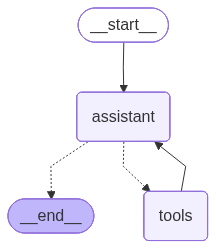

In [4]:
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display

def assistant(state: MessagesState):
    sys_msg = "You are a helpful assistant that can search the web to answer questions. Always cite your sources."
    return {"messages": llm_with_tools.invoke([SystemMessage(sys_msg)] + state["messages"])}

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
messages = [HumanMessage(content="What are the top 3 trending AI tools right now?")]
output = graph.invoke({"messages": messages})

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are the top 3 trending AI tools right now?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_02GlSqj5JTHfbwYVTGWbFE46)
 Call ID: call_02GlSqj5JTHfbwYVTGWbFE46
  Args:
    query: top trending AI tools 2026 latest popular AI tools current trends
  tavily_search_results_json (call_Yn1ZJ8cTExOKdqEA9fuay6S7)
 Call ID: call_Yn1ZJ8cTExOKdqEA9fuay6S7
  Args:
    query: most popular AI tools right now 2026 trend articles
  tavily_search_results_json (call_MF7NJyu0Vys1JCIzV1d7GPoo)
 Call ID: call_MF7NJyu0Vys1JCIzV1d7GPoo
  Args:
    query: AI tool trends 2026 top tools ChatGPT Claude Gemini Perplexity recent
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The best AI productivity tools in 2026 - Zapier", "url": "https://zapier.com/blog/best-ai-productivity

---
## Step 4: Adding Memory

Right now, each `invoke()` call starts fresh — the agent has no memory of previous conversations. Let's fix that.

<img src="./assets-resources/2025-02-10-16-25-13.png" width=50%>

### Key Concepts

- **Memory**: The ability to process, store, and recall information from past interactions
- **Persistence**: LangGraph saves snapshots of graph state using **checkpointers** at every superstep
- **Threads**: Individual sessions/conversations identified by a unique `thread_id`
- **Checkpoints**: Saved state snapshots that enable resumption, time-travel, and human-in-the-loop

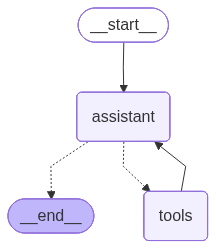

In [6]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Re-compile the same graph, but now with a checkpointer
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

### Using Thread IDs

The `thread_id` in the config tells the checkpointer which conversation to load/save. Same thread = same conversation history.

In [7]:
config = {"configurable": {"thread_id": "1"}}

# First message in thread 1
messages = [HumanMessage(content="What is the weather in Tokyo?")]
output = graph.invoke({"messages": messages}, config)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the weather in Tokyo?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_BhNHv28V47ZqkmV1j8H3f7er)
 Call ID: call_BhNHv28V47ZqkmV1j8H3f7er
  Args:
    query: Tokyo weather current conditions today
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Tokyo, Japan 14 day weather forecast", "url": "https://www.timeanddate.com/weather/japan/tokyo/ext", "content": "---  ---  ---  ---  ---  --- \n| \\ Updated Monday, April 6, 2026 12:24:06 pm Tokyo time - Weather by CustomWeather, © 2026 | | | | | | | | | | | | | [...] |  | Conditions | | | Comfort | | | | Precipitation | | Sun | | |\n ---  ---  ---  ---  ---  --- \n| Day |  | Temperature | Weather | Feels Like | Wind |  | Humidity | Chance | Amount | UV | Sunrise | Sunset |\n| Mon Apr 6 |  | 74 / 57 °F |

In [8]:
# Follow-up in the SAME thread — the agent remembers!
new_message = HumanMessage(content="What was the city from the previous question?")
output = graph.invoke({"messages": [new_message]}, config)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the weather in Tokyo?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_BhNHv28V47ZqkmV1j8H3f7er)
 Call ID: call_BhNHv28V47ZqkmV1j8H3f7er
  Args:
    query: Tokyo weather current conditions today
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Tokyo, Japan 14 day weather forecast", "url": "https://www.timeanddate.com/weather/japan/tokyo/ext", "content": "---  ---  ---  ---  ---  --- \n| \\ Updated Monday, April 6, 2026 12:24:06 pm Tokyo time - Weather by CustomWeather, © 2026 | | | | | | | | | | | | | [...] |  | Conditions | | | Comfort | | | | Precipitation | | Sun | | |\n ---  ---  ---  ---  ---  --- \n| Day |  | Temperature | Weather | Feels Like | Wind |  | Humidity | Chance | Amount | UV | Sunrise | Sunset |\n| Mon Apr 6 |  | 74 / 57 °F |

In [9]:
# A DIFFERENT thread — isolated conversation, no memory of thread 1
config2 = {"configurable": {"thread_id": "2"}}

output = graph.invoke(
    {"messages": [HumanMessage(content="What was the city from the previous question?")]},
    config2
)

# The agent won't know — this is a fresh thread
for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

What was the city from the previous question?
================================== Ai Message ==================================

I don’t have the previous question in this chat context, so I can’t tell which city you mean.

If you paste the previous question here, I can identify the city.


---
## Summary

| What we built | Key API |
|---------------|--------|
| ReAct agent with web search | `ToolNode`, `tools_condition`, `TavilySearchResults` |
| Persistent memory | `MemorySaver`, `thread_id` in config |
| Isolated conversations | Different `thread_id` values |

**Next**: In Notebook 3, we'll build a RAG agent that retrieves from documents and can fall back to web search.